Asah led by Dicoding 2025

**Capstone Project Team ID:** A25-CS327  
**Project Title:** *Customer Segmentation Using RFM Analysis and Clustering for Customer Value Profiling*  
**Selected Case:** AC-06 - Customer Segmentation for Personalized Retail Marketing  
**Capstone Advisor:** A25-AD196 - Raihan Nugroho Jauhari - 29/11/2025

| ID Member      | Name                     | Role              | Status   |
|----------------|--------------------------|-------------------|----------|
| M284D5Y0552    | Fadhil Muhamad           | Machine Learning  | Active   |
| M284D5Y1165    | Muh. Hilmy Fahrizal      | Machine Learning  | Active   |
| M015D5X1483    | Naysa Syifa Nuristiani   | Machine Learning  | Active   |


Import Library

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import datetime as dt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn.metrics import davies_bouldin_score
from matplotlib.patches import Patch
import matplotlib.ticker as mtick
import matplotlib.dates as mdates

import streamlit
import plotly
import sklearn

print(f"streamlit=={streamlit.__version__}")
print(f"pandas=={pd.__version__}")
print(f"matplotlib=={plt.matplotlib.__version__}")
print(f"seaborn=={sns.__version__}")
print(f"plotly=={plotly.__version__}")
print(f"scikit-learn=={sklearn.__version__}")
print(f"numpy=={np.__version__}")

streamlit==1.41.1
pandas==2.2.2
matplotlib==3.8.0
seaborn==0.13.2
plotly==5.24.1
scikit-learn==1.6.1
numpy==1.26.4


## **Exploratory Data Analysis** & **Preprocessing**

Dataset source:

[**Online Retail II – UCI (Kaggle)**](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci)

Check data types and example.

In [39]:
df_raw = pd.read_csv("..\Data\online_retail_II.csv")
print(df_raw.info())
df_raw

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
None


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


Check missing values.

In [40]:
print("Missing Values:")
print(df_raw.isnull().sum())

Missing Values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


Check most frequent values for every categorical column.

In [41]:
cat_cols = df_raw.select_dtypes(include="object").columns
for col in cat_cols:
    print(f"\nTotal values: {col}")
    print(df_raw[col].value_counts().head())


Total values: Invoice
Invoice
537434    1350
538071    1304
537638    1202
537237    1194
536876    1186
Name: count, dtype: int64

Total values: StockCode
StockCode
85123A    5829
22423     4424
85099B    4216
21212     3318
20725     3259
Name: count, dtype: int64

Total values: Description
Description
WHITE HANGING HEART T-LIGHT HOLDER    5918
REGENCY CAKESTAND 3 TIER              4412
JUMBO BAG RED RETROSPOT               3469
ASSORTED COLOUR BIRD ORNAMENT         2958
PARTY BUNTING                         2765
Name: count, dtype: int64

Total values: InvoiceDate
InvoiceDate
2010-12-06 16:57:00    1350
2010-12-09 14:09:00    1304
2010-12-07 15:28:00    1202
2010-12-06 09:58:00    1194
2010-12-03 11:36:00    1186
Name: count, dtype: int64

Total values: Country
Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Name: count, dtype: int64


Explanation of Key Variables

- **Customer ID**  
  Used to uniquely identify each customer.

- **InvoiceDate**  
  Used to calculate **Recency** — how long it has been since the customer's last purchase.

- **Quantity**  
  Used to calculate **Monetary** — representing the number of items purchased.

- **Price**  
  Used to calculate **Monetary** — total spending is computed as:  
  **Total Monetary = Quantity × Price**

- **Invoice**  
  Used to calculate **Frequency** — indicating how many times a customer has made a purchase.

Copy only Key Variables

In [42]:
df = df_raw[['Customer ID', 'InvoiceDate', 'Quantity', 'Price', 'Invoice']].copy()
df.head()

,Customer ID,InvoiceDate,Quantity,Price,Invoice
0,13085.0,2009-12-01 07:45:00,12,6.95,489434
1,13085.0,2009-12-01 07:45:00,12,6.75,489434
2,13085.0,2009-12-01 07:45:00,12,6.75,489434
3,13085.0,2009-12-01 07:45:00,48,2.10,489434
4,13085.0,2009-12-01 07:45:00,24,1.25,489434



Handling Missing Values

In [43]:
print(f"Missing Customer ID: {df_raw['Customer ID'].isna().sum()}")

len_before = len(df)
df = df.dropna(subset=['Customer ID'])

print(f"After removing missing Customer ID: {len(df)} (Removed {len_before - len(df)} transactions)")

Missing Customer ID: 243007
After removing missing Customer ID: 824364 (Removed 243007 transactions)


Handling Canceled Transactions

In [44]:
len_before = len(df)

cancelation = df_raw[df_raw['Invoice'].astype(str).str.startswith('C')]
df = df[~df['Invoice'].astype(str).str.startswith('C')]

cancelation_cols = ['Invoice', 'Customer ID', 'Quantity', 'Price']
print("\nSample of Credit Note / Return Transactions")
print(cancelation[cancelation_cols].head())

print(f"After removing cancelations: {len(df)} (removed {len_before - len(df)} transactions)")


Sample of Credit Note / Return Transactions
     Invoice  Customer ID  Quantity  Price
178  C489449      16321.0       -12   2.95
179  C489449      16321.0        -6   1.65
180  C489449      16321.0        -4   4.25
181  C489449      16321.0        -6   2.10
182  C489449      16321.0       -12   2.95
After removing cancelations: 805620 (removed 18744 transactions)


Handling Invalid Data

In [45]:
len_before = len(df)

df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

print(f"After removing Quantity/Price <= 0: {len(df)} (removed {len_before - len(df)} transactions)")

After removing Quantity/Price <= 0: 805549 (removed 71 transactions)


Handling Duplicates

In [46]:
len_before = len(df)

duplicates = df[df.duplicated(keep=False)]
if not duplicates.empty:
    print("\nExample of Duplicate Transactions")
    print(duplicates.head())

df = df.drop_duplicates()

print(f"After removing duplicates: {len(df)} (removed {len_before - len(df)} transactions)")


Example of Duplicate Transactions
   Customer ID          InvoiceDate  Quantity  Price Invoice
1      13085.0  2009-12-01 07:45:00        12   6.75  489434
2      13085.0  2009-12-01 07:45:00        12   6.75  489434
4      13085.0  2009-12-01 07:45:00        24   1.25  489434
6      13085.0  2009-12-01 07:45:00        24   1.25  489434
8      13085.0  2009-12-01 07:46:00        12   2.55  489435
After removing duplicates: 490658 (removed 314891 transactions)


Define Revenue (for Monetary preparation)

In [47]:
df['Revenue'] = df['Quantity'] * df['Price']
print("\nRevenue Sample:")
print(df[['Quantity', 'Price', 'Revenue']].head())


Revenue Sample:
   Quantity  Price  Revenue
0        12   6.95     83.4
1        12   6.75     81.0
3        48   2.10    100.8
4        24   1.25     30.0
5        24   1.65     39.6


Datetime Format & Reference Date (for Recency preparation)

In [48]:
print("InvoiceDate dtype before:", df['InvoiceDate'].dtype)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("\nInvoiceDate dtype after:", df['InvoiceDate'].dtype)

min_date = df['InvoiceDate'].min()
max_date = df['InvoiceDate'].max()

print(f"\nData covers from {min_date.date()} to {max_date.date()}")

reference_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
print("\nReference date:", reference_date)


InvoiceDate dtype before: object

InvoiceDate dtype after: datetime64[ns]

Data covers from 2009-12-01 to 2011-12-09

Reference date: 2011-12-10 12:50:00


In [49]:
df.columns

Index(['Customer ID', 'InvoiceDate', 'Quantity', 'Price', 'Invoice',
       'Revenue'],
      dtype='object')

Check Customer & Revenue

In [50]:
customer_revenue = df.groupby('Customer ID')['Revenue'].sum().reset_index()

num_customers = customer_revenue['Customer ID'].nunique()
total_revenue = customer_revenue['Revenue'].sum()

print(f"Total customer: {num_customers}")
print(f"Total revenue: {total_revenue:,.0f}")

Total customer: 5878
Total revenue: 12,903,089


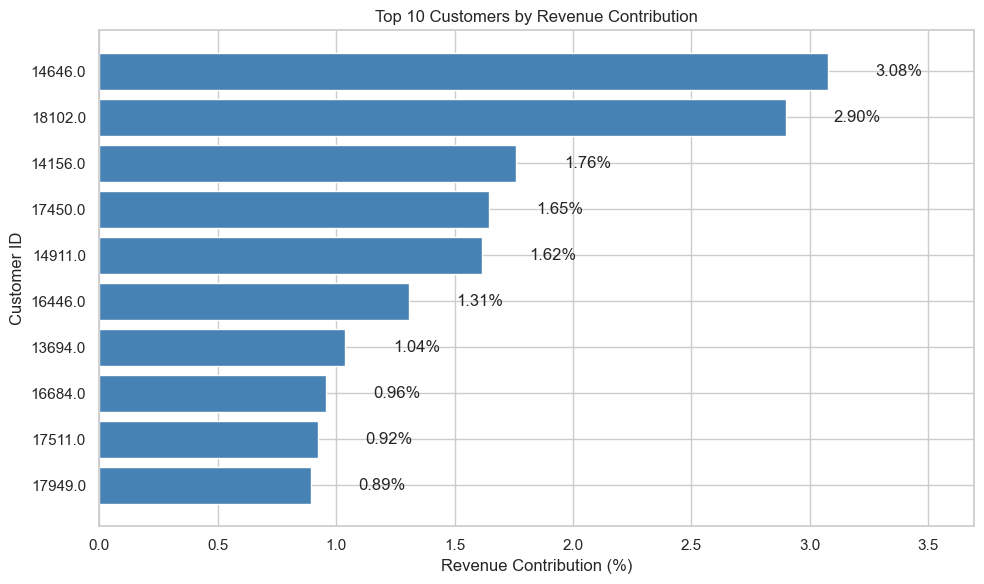

In [51]:
customer_revenue_sorted = customer_revenue.sort_values(by='Revenue', ascending=False)

top_n = 10
top_customers = customer_revenue_sorted.head(10).copy()
top_customers['Revenue_pct'] = top_customers['Revenue'] / total_revenue * 100

plt.figure(figsize=(10,6))
bars = plt.barh(
    y=top_customers['Customer ID'].astype(str),
    width=top_customers['Revenue_pct'],
    color='steelblue'
)

plt.gca().invert_yaxis()
plt.xlim(0, max(top_customers['Revenue_pct']) * 1.2)

for bar, pct in zip(bars, top_customers['Revenue_pct']):
    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height()/2,
        f'{pct:.2f}%',
        va='center'
    )

plt.xlabel('Revenue Contribution (%)')
plt.ylabel('Customer ID')
plt.title('Top 10 Customers by Revenue Contribution')
plt.tight_layout()
plt.show()

Check Revenue Overtime

In [52]:
print("\nMonths covered in the dataset:")
print(df['InvoiceDate'].dt.to_period('M').unique())


Months covered in the dataset:
<PeriodArray>
['2009-12', '2010-01', '2010-02', '2010-03', '2010-04', '2010-05', '2010-06',
 '2010-07', '2010-08', '2010-09', '2010-10', '2010-11', '2010-12', '2011-01',
 '2011-02', '2011-03', '2011-04', '2011-05', '2011-06', '2011-07', '2011-08',
 '2011-09', '2011-10', '2011-11', '2011-12']
Length: 25, dtype: period[M]


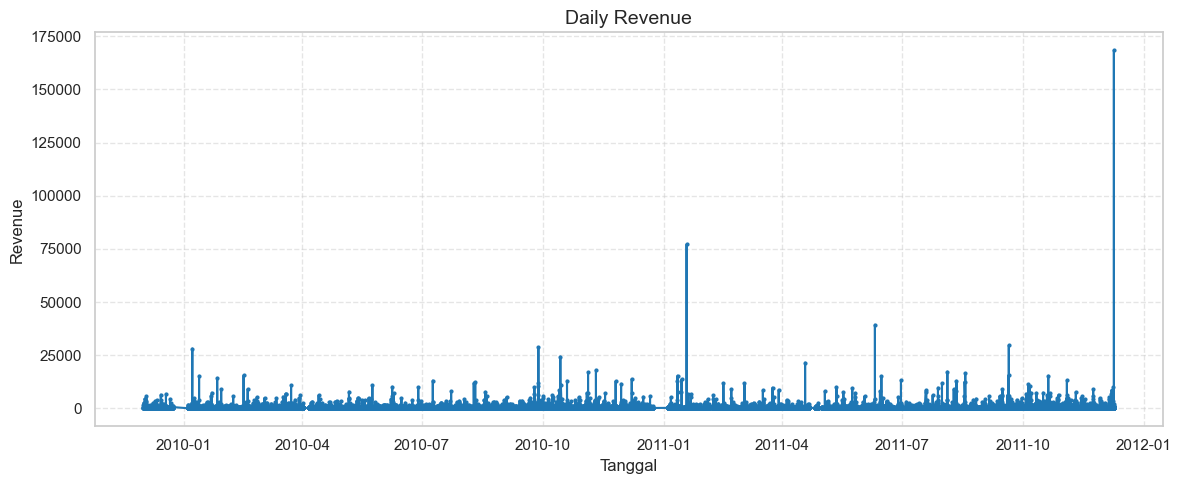

In [53]:
daily_revenue = df.groupby('InvoiceDate')['Revenue'].sum()

plt.figure(figsize=(12,5))
plt.plot(daily_revenue.index, daily_revenue, color='tab:blue', linewidth=1.5, marker='.', markersize=4)
plt.title('Daily Revenue', fontsize=14)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

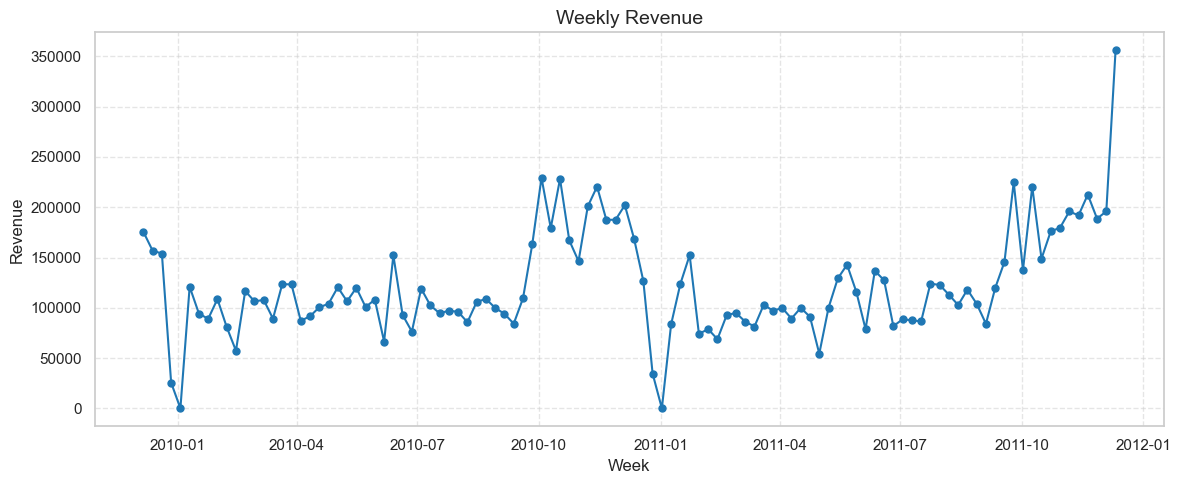

In [54]:
weekly_revenue = df.groupby('InvoiceDate')['Revenue'].sum().resample('W').sum()

plt.figure(figsize=(12,5))
plt.plot(weekly_revenue.index, weekly_revenue, color='tab:blue', linewidth=1.5, marker='o', markersize=5)
plt.title('Weekly Revenue', fontsize=14)
plt.xlabel('Week', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

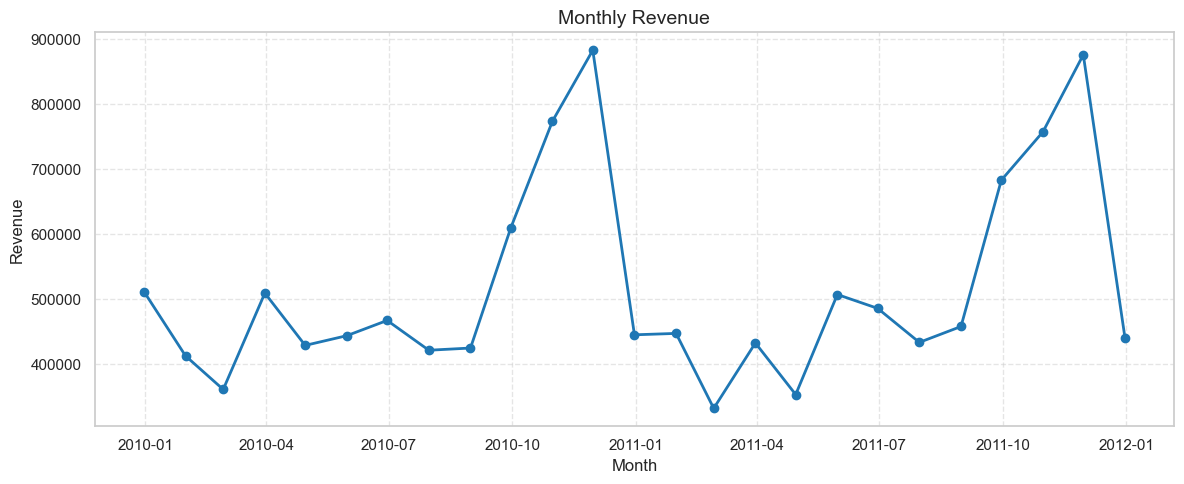

In [55]:
monthly_revenue = df.groupby('InvoiceDate')['Revenue'].sum().resample('ME').sum()

plt.figure(figsize=(12,5))
plt.plot(monthly_revenue.index, monthly_revenue, color='tab:blue', linewidth=2, marker='o', markersize=6)
plt.title('Monthly Revenue', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

##### Recency (R)
- Measures how long it has been since a customer's last transaction.
- Calculated from the **reference_date** (the date used as the analysis reference).
- The smaller the recency value, the more recent the customer interaction.

##### Frequency (F)
- Measures how often a customer makes transactions.
- Calculated from the number of **unique invoices** per customer.
- The higher the frequency value, the more often the customer transacts.

##### Monetary (M)
- Measures the total spending of a customer.
- Calculated from the total **revenue** per customer.
- The higher the monetary value, the greater the customer's contribution.


~

- **Recency** = `reference_date - last_transaction_date`
- **Frequency** = `number_of_unique_invoices_per_customer`
- **Monetary** = `total_revenue_per_customer`

In [56]:
def calculate_rfm(df, reference_date):
    data = df.copy()
    rfm = (
        data.groupby('Customer ID')
            .agg({
                'InvoiceDate': lambda x: (reference_date - x.max()).days,   # Recency
                'Invoice': 'nunique',                                       # Frequency
                'Revenue': 'sum'                                            # Monetary
            })
            .rename(columns={
                'InvoiceDate': 'Recency',
                'Invoice': 'Frequency',
                'Revenue': 'Monetary'
            })
            .reset_index()
    )
    return rfm

rfm = calculate_rfm(df, reference_date)

print("\nExample of RFM table per customer:")
rfm.head()


Example of RFM table per customer:


,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77403.79
1,12347.0,2,8,3434.23
2,12348.0,75,5,1448.56
3,12349.0,19,4,3018.85
4,12350.0,310,1,174.20


Check RFM Distribution

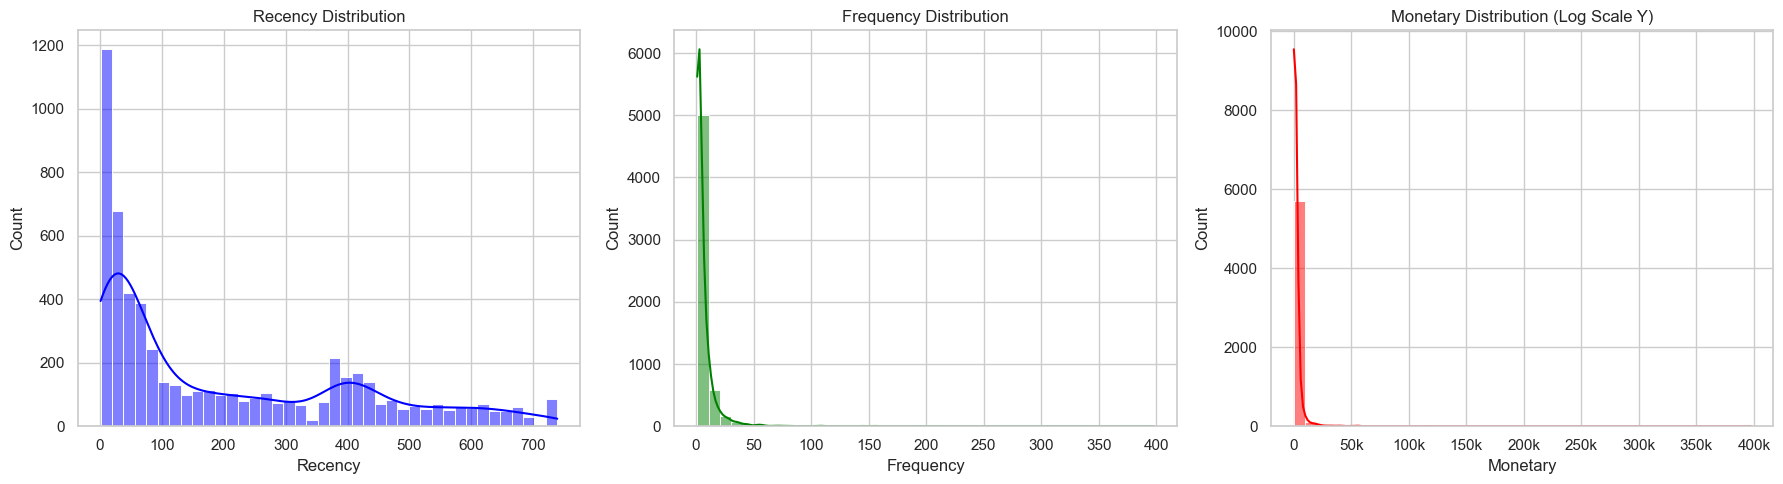

In [57]:
plt.figure(figsize=(18, 5))
sns.set_theme(style="whitegrid")

plt.subplot(1, 3, 1)
sns.histplot(rfm['Recency'], kde=True, bins=40, color='blue')
plt.title("Recency Distribution")

plt.subplot(1, 3, 2)
sns.histplot(rfm['Frequency'], kde=True, bins=40, color='green')
plt.title("Frequency Distribution")

def thousands_formatter(x, pos):
    if x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif x >= 1_000:
        return f"{int(x/1000)}k"
    else:
        return str(int(x))

plt.subplot(1, 3, 3)
sns.histplot(rfm['Monetary'], kde=True, bins=40, color='red')
plt.title("Monetary Distribution (Log Scale Y)")

plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(thousands_formatter))

plt.tight_layout()
plt.show()

## Traditional RFM Scoring

In [58]:
R_Score = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
F_Score = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
M_Score = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm_score = pd.DataFrame({
    'Customer ID': rfm['Customer ID'],
    'R_Score': R_Score,
    'F_Score': F_Score,
    'M_Score': M_Score
})

rfm_score['RFM_Score'] = (
    rfm_score['R_Score'].astype(str) +
    rfm_score['F_Score'].astype(str) +
    rfm_score['M_Score'].astype(str)
)

print("\nExample of RFM Score")
rfm_score.head()


Example of RFM Score


,Customer ID,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,2,5,5,255
1,12347.0,5,4,5,545
2,12348.0,3,4,4,344
3,12349.0,5,3,5,535
4,12350.0,2,1,1,211


Check which R-F score combinations produce the highest revenue

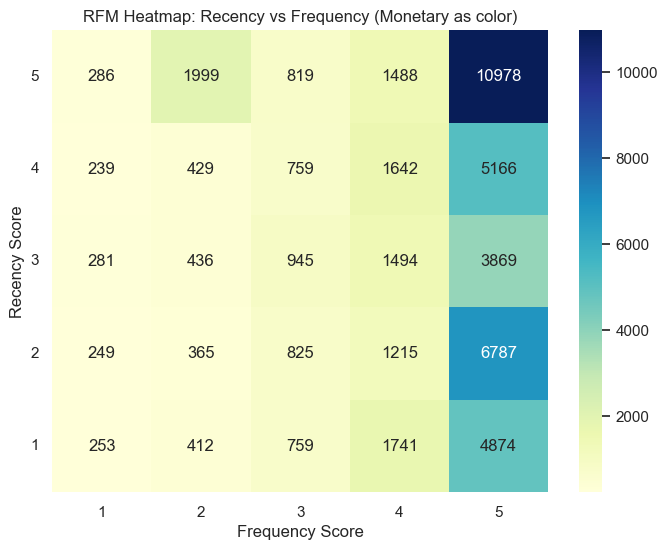

In [59]:
rfm_plot = rfm.join(rfm_score.set_index('Customer ID'), on='Customer ID')

heatmap_data = rfm_plot.groupby(['R_Score', 'F_Score'], observed=True)['Monetary'].mean().unstack()

plt.figure(figsize=(8,6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu")

plt.title("RFM Heatmap: Recency vs Frequency (Monetary as color)")
plt.xlabel("Frequency Score")
plt.ylabel("Recency Score")

plt.yticks(rotation=0)
plt.show()

Data Normalization (MinMax)

In [60]:
rfm_clust = rfm[['Recency','Frequency','Monetary']].copy()
scaler = MinMaxScaler()
rfm_scaled = scaler.fit_transform(rfm_clust)

# **Clustering**

Validation for Optimal Cluster

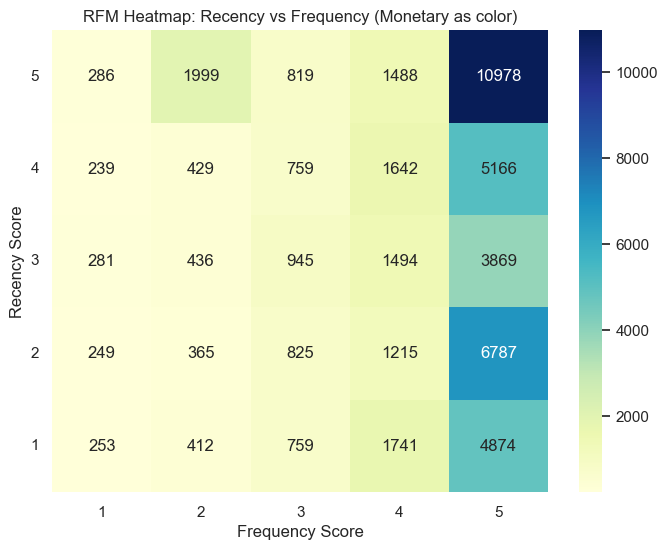

Optimal cluster based on combined score: k = 4


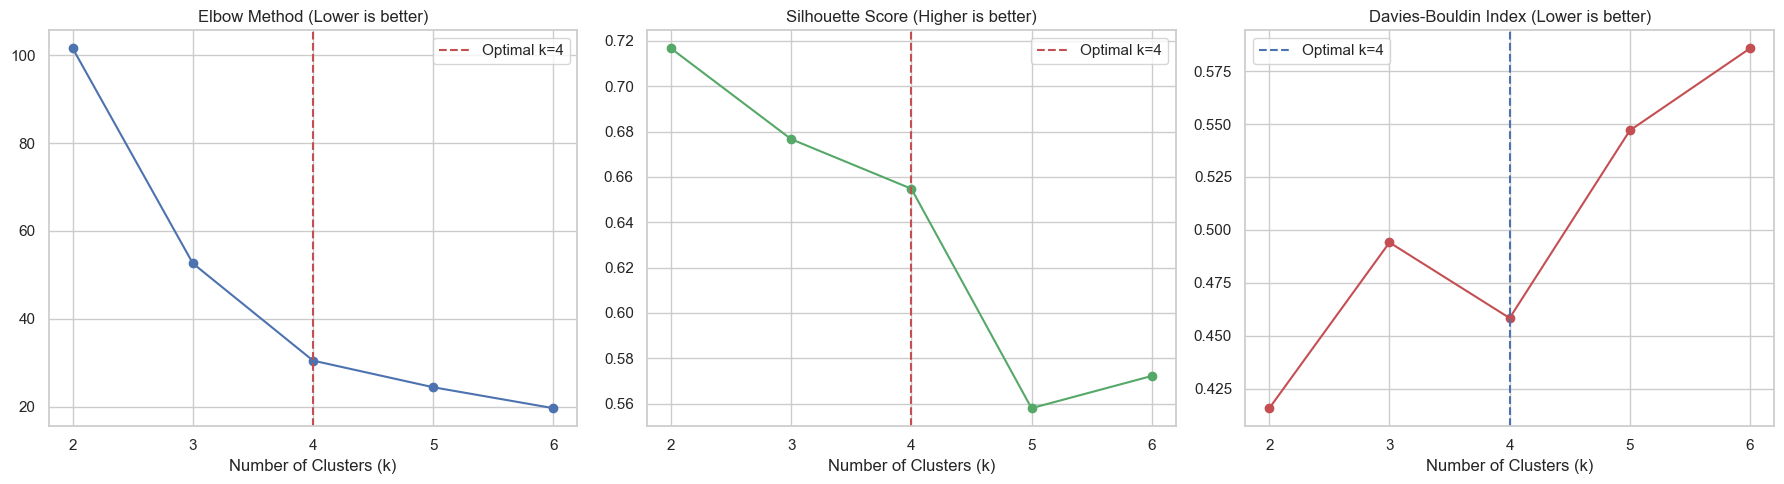

In [61]:
df_raw = pd.read_csv("../Data/online_retail_II.csv")
df = df_raw[['Customer ID', 'InvoiceDate', 'Quantity', 'Price', 'Invoice']].copy()
df = df.dropna(subset=['Customer ID'])
cancelation = df_raw[df_raw['Invoice'].astype(str).str.startswith('C')]
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
df = df.drop_duplicates()
df['Revenue'] = df['Quantity'] * df['Price']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
reference_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

def calculate_rfm(df, reference_date):
    data = df.copy()
    rfm = (
        data.groupby('Customer ID')
            .agg({
                'InvoiceDate': lambda x: (reference_date - x.max()).days,   # Recency
                'Invoice': 'nunique',                                       # Frequency
                'Revenue': 'sum'                                            # Monetary
            })
            .rename(columns={
                'InvoiceDate': 'Recency',
                'Invoice': 'Frequency',
                'Revenue': 'Monetary'
            })
            .reset_index()
    )
    return rfm
rfm = calculate_rfm(df, reference_date)

R_Score = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
F_Score = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
M_Score = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm_score = pd.DataFrame({
    'Customer ID': rfm['Customer ID'],
    'R_Score': R_Score,
    'F_Score': F_Score,
    'M_Score': M_Score
})

rfm_score['RFM_Score'] = (
    rfm_score['R_Score'].astype(str) +
    rfm_score['F_Score'].astype(str) +
    rfm_score['M_Score'].astype(str)
)

rfm_plot = rfm.join(rfm_score.set_index('Customer ID'), on='Customer ID')

heatmap_data = rfm_plot.groupby(['R_Score', 'F_Score'], observed=True)['Monetary'].mean().unstack()

plt.figure(figsize=(8,6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu")

plt.title("RFM Heatmap: Recency vs Frequency (Monetary as color)")
plt.xlabel("Frequency Score")
plt.ylabel("Recency Score")

plt.yticks(rotation=0)
plt.show()

rfm_clust = rfm[['Recency','Frequency','Monetary']].copy()
scaler = MinMaxScaler()
rfm_scaled = scaler.fit_transform(rfm_clust)

K = range(2, 7)
sse = []
sil_scores = []
dbi_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)

    sse.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, labels))
    dbi_scores.append(davies_bouldin_score(rfm_scaled, labels))

sse_arr = np.array(sse).reshape(-1,1)
sse_norm = MinMaxScaler().fit_transform(sse_arr).flatten()

sil_arr = np.array(sil_scores).reshape(-1,1)
sil_norm = MinMaxScaler().fit_transform(sil_arr).flatten()

dbi_arr = np.array(dbi_scores).reshape(-1,1)
dbi_norm = MinMaxScaler().fit_transform(dbi_arr).flatten()

combined_scores = []
for i, k in enumerate(K):
    final_score = 0.33 * (1 - sse_norm[i]) + 0.34 * sil_norm[i] + 0.33 * (1 - dbi_norm[i])
    combined_scores.append((k, final_score))

k_opt = max(combined_scores, key=lambda x: x[1])[0]
print(f"Optimal cluster based on combined score: k = {k_opt}")

fig, axs = plt.subplots(1,3,figsize=(18,5))

# Elbow Method (SSE)
axs[0].plot(K, sse, marker='o', color='b')
axs[0].axvline(k_opt, color='r', linestyle='--', label=f'Optimal k={k_opt}')
axs[0].set_title('Elbow Method (Lower is better)')
axs[0].set_xlabel('Number of Clusters (k)')
axs[0].set_xticks(list(K))
axs[0].grid(True)
axs[0].legend()

# Silhouette Score
axs[1].plot(K, sil_scores, marker='o', color='g')
axs[1].axvline(k_opt, color='r', linestyle='--', label=f'Optimal k={k_opt}')
axs[1].set_title('Silhouette Score (Higher is better)')
axs[1].set_xlabel('Number of Clusters (k)')
axs[1].set_xticks(list(K))
axs[1].grid(True)
axs[1].legend()

# Davies-Bouldin Index
axs[2].plot(K, dbi_scores, marker='o', color='r')
axs[2].axvline(k_opt, color='b', linestyle='--', label=f'Optimal k={k_opt}')
axs[2].set_title('Davies-Bouldin Index (Lower is better)')
axs[2].set_xlabel('Number of Clusters (k)')
axs[2].set_xticks(list(K))
axs[2].grid(True)
axs[2].legend()

plt.tight_layout()
plt.show()

Optimal cluster based on combined score: k = 4


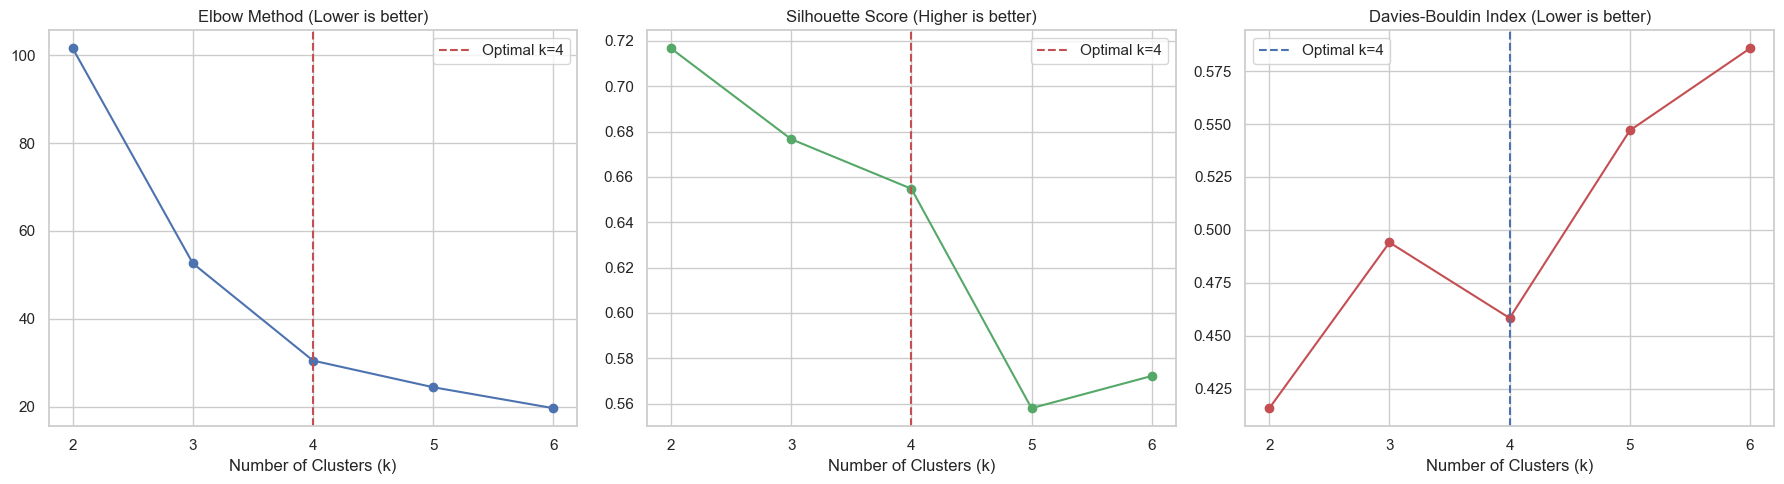

In [62]:
K = range(2, 7)
sse = []
sil_scores = []
dbi_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)

    sse.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, labels))
    dbi_scores.append(davies_bouldin_score(rfm_scaled, labels))

sse_arr = np.array(sse).reshape(-1,1)
sse_norm = MinMaxScaler().fit_transform(sse_arr).flatten()

sil_arr = np.array(sil_scores).reshape(-1,1)
sil_norm = MinMaxScaler().fit_transform(sil_arr).flatten()

dbi_arr = np.array(dbi_scores).reshape(-1,1)
dbi_norm = MinMaxScaler().fit_transform(dbi_arr).flatten()

combined_scores = []
for i, k in enumerate(K):
    final_score = 0.33 * (1 - sse_norm[i]) + 0.34 * sil_norm[i] + 0.33 * (1 - dbi_norm[i])
    combined_scores.append((k, final_score))

k_opt = max(combined_scores, key=lambda x: x[1])[0]
print(f"Optimal cluster based on combined score: k = {k_opt}")

fig, axs = plt.subplots(1,3,figsize=(18,5))

# Elbow Method (SSE)
axs[0].plot(K, sse, marker='o', color='b')
axs[0].axvline(k_opt, color='r', linestyle='--', label=f'Optimal k={k_opt}')
axs[0].set_title('Elbow Method (Lower is better)')
axs[0].set_xlabel('Number of Clusters (k)')
axs[0].set_xticks(list(K))
axs[0].grid(True)
axs[0].legend()

# Silhouette Score
axs[1].plot(K, sil_scores, marker='o', color='g')
axs[1].axvline(k_opt, color='r', linestyle='--', label=f'Optimal k={k_opt}')
axs[1].set_title('Silhouette Score (Higher is better)')
axs[1].set_xlabel('Number of Clusters (k)')
axs[1].set_xticks(list(K))
axs[1].grid(True)
axs[1].legend()

# Davies-Bouldin Index
axs[2].plot(K, dbi_scores, marker='o', color='r')
axs[2].axvline(k_opt, color='b', linestyle='--', label=f'Optimal k={k_opt}')
axs[2].set_title('Davies-Bouldin Index (Lower is better)')
axs[2].set_xlabel('Number of Clusters (k)')
axs[2].set_xticks(list(K))
axs[2].grid(True)
axs[2].legend()

plt.tight_layout()
plt.show()

In [63]:
rfm.columns

Index(['Customer ID', 'Recency', 'Frequency', 'Monetary'], dtype='object')

Modeling

In [64]:
kmeans_final = KMeans(n_clusters=k_opt, random_state=42)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

cluster_size = rfm['Cluster'].value_counts().sort_index()
cluster_size

Cluster
0     989
1    3145
2    1107
3     637
Name: count, dtype: int64

In [65]:
rfm.columns

Index(['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Cluster'], dtype='object')

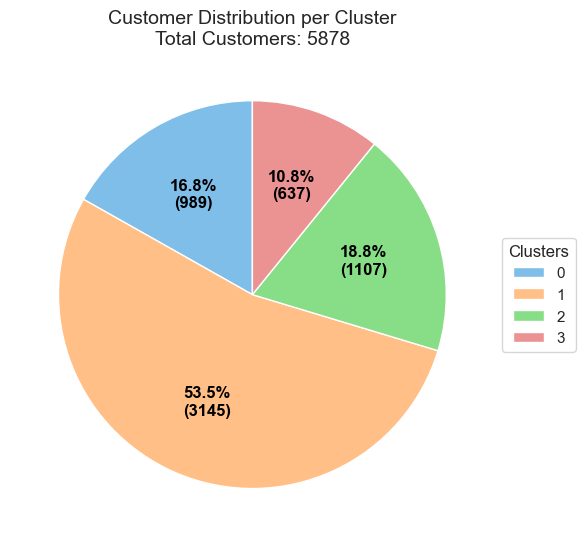

In [66]:
clusters = cluster_size.index
counts = cluster_size.values

base_colors = plt.cm.tab10.colors[:len(clusters)]

def lighten_color(color, amount=0.5):
    import colorsys
    try:
        c = mcolors.cnames[color]
    except:
        c = color
    c = mcolors.to_rgb(c)
    c = colorsys.rgb_to_hls(*c)

    lightened = colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])
    return lightened

colors = [lighten_color(c, 0.5) for c in base_colors]

def autopct_format(pct, all_vals):
    absolute = int(round(pct/100.*sum(all_vals)))
    return f"{pct:.1f}%\n({absolute})"

fig, ax = plt.subplots(figsize=(6,6))

pie_result = ax.pie(
    counts,
    labels=None,
    autopct=lambda pct: autopct_format(pct, counts),
    startangle=90,
    colors=colors,
    textprops={'fontsize': 12, 'color': 'black', 'weight': 'bold'}
)

wedges = pie_result[0]

ax.legend(wedges, clusters, title="Clusters", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
ax.set_title(f"Customer Distribution per Cluster\nTotal Customers: {counts.sum()}", fontsize=14)

plt.tight_layout()
plt.show()

Cluster Statistics

In [67]:
cluster_profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(2)
rfm_profile = cluster_profile.rename(columns={
    'Recency': 'Recency (days)',
    'Frequency': 'Frequency (transactions)',
    'Monetary': 'Monetary (£)'
})

rfm_profile

,Recency (days),Frequency (transactions),Monetary (£)
Cluster,,,
0,213.31,3.71,1032.79
1,37.89,9.31,3416.97
2,412.85,2.72,751.34
3,622.08,1.55,476.54


In [68]:
cluster_profile_median = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].median().round()
cluster_profile_median

,Recency,Frequency,Monetary
Cluster,,,
0,211.0,3.0,497.0
1,29.0,5.0,1151.0
2,409.0,2.0,340.0
3,619.0,1.0,194.0


In [69]:
ratio_mean_median = (cluster_profile / cluster_profile_median).round(2)
print("Mean / Median Ratio per cluster:")
ratio_mean_median

Mean / Median Ratio per cluster:


,Recency,Frequency,Monetary
Cluster,,,
0,1.01,1.24,2.08
1,1.31,1.86,2.97
2,1.01,1.36,2.21
3,1.00,1.55,2.46


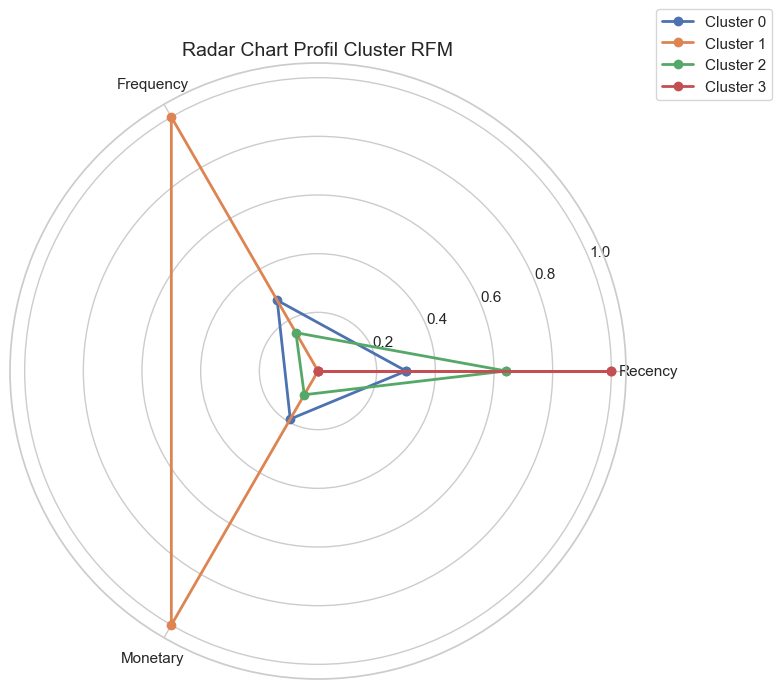

In [70]:
rfm_cols = ['Recency', 'Frequency', 'Monetary']
N = len(rfm_cols)

cluster_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())

plt.figure(figsize=(8,8))

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

for idx, row in cluster_norm.iterrows():
    values = row.tolist()
    values += values[:1]
    plt.polar(angles, values, marker='o', linewidth=2, label=f'Cluster {idx}')

plt.xticks(angles[:-1], rfm_cols)
plt.title("Radar Chart Profil Cluster RFM", fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))
plt.show()

Check the distribution of Recency for each cluster

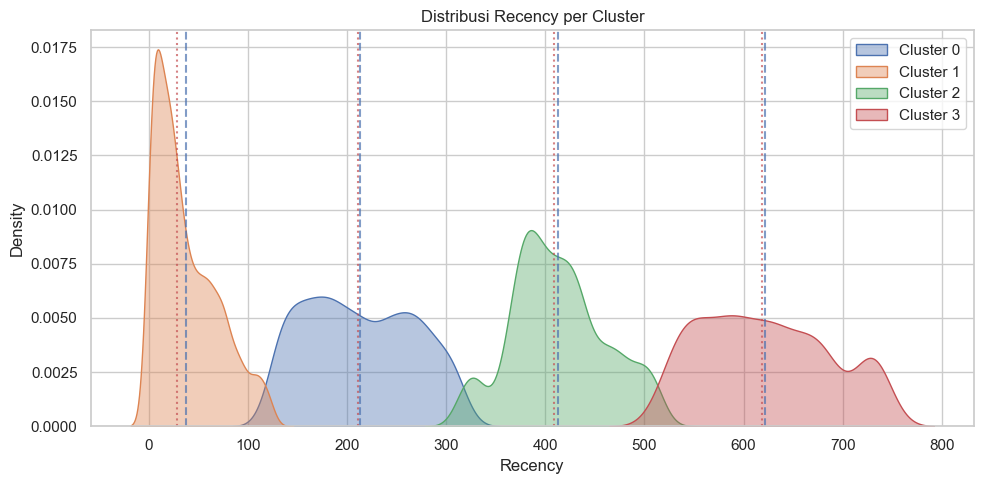

In [71]:
col = 'Recency'
num_clusters = cluster_profile.shape[0]

plt.figure(figsize=(10,5))

for cluster in range(num_clusters):
    sns.kdeplot(
        rfm[rfm['Cluster']==cluster][col],
        label=f'Cluster {cluster}',
        fill=True, alpha=0.4
    )
    plt.axvline(cluster_profile.loc[cluster, col], color='b', linestyle='--', alpha=0.7)
    plt.axvline(cluster_profile_median.loc[cluster, col], color='r', linestyle=':', alpha=0.7)

plt.title('Distribusi Recency per Cluster')
plt.xlabel('Recency')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

for Frequency and Monetary, the distributions are extremely skewed, so they cannot be visualized effectively, just like RFM distribution initially.

Differences across Recency, Frequency, and Monetary profiles

In [72]:
def plot_rfm_radar(cluster_profile):
    """
    Plot RFM cluster profile as a radar chart.
    
    cluster_profile: DataFrame with clusters as index and R/F/M columns
    """
    rfm_columns = ['Recency', 'Frequency', 'Monetary']
    num_metrics = len(rfm_columns)

    # Normalize values for radar chart (0-1)
    cluster_normalized = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())

    angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
    angles += angles[:1]  # close the loop

    colors = plt.cm.tab10.colors

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, polar=True)

    for idx, row in cluster_normalized.iterrows():
        values = row.tolist()
        values += values[:1]  # close the loop
        ax.plot(angles, values, marker='o', linewidth=2, label=f'Cluster {idx}', color=colors[idx % len(colors)])
        ax.fill(angles, values, color=colors[idx % len(colors)], alpha=0.2)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(rfm_columns, fontsize=12)
    ax.set_yticks(np.linspace(0, 1, 5))
    ax.set_yticklabels([f"{y:.1f}" for y in np.linspace(0, 1, 5)], fontsize=10)
    ax.set_title("RFM Cluster Profile Radar Chart", fontsize=16, fontweight='bold')

    ax.grid(color='gray', linestyle='--', linewidth=0.5)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

    plt.tight_layout()
    st.pyplot(fig)


Shows how clusters are separated in RFM space

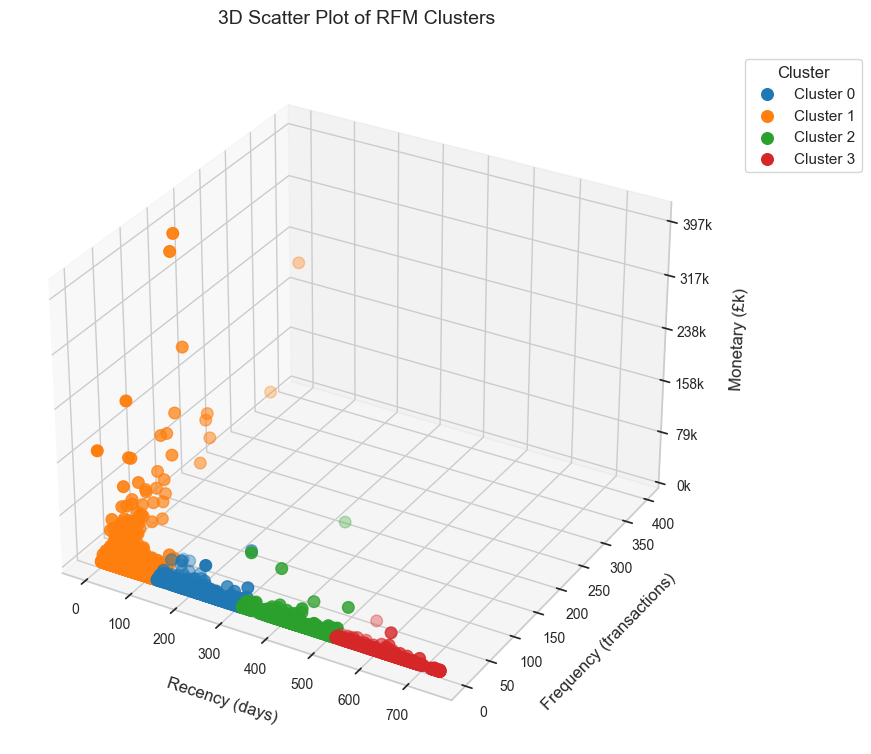

In [73]:
num_clusters = rfm['Cluster'].nunique()
colors = sns.color_palette("tab10", n_colors=num_clusters)

fig = plt.figure(figsize=(12,9))
ax = fig.add_subplot(111, projection='3d')

for cluster in range(num_clusters):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    ax.scatter(
        cluster_data['Recency'],
        cluster_data['Frequency'],
        cluster_data['Monetary'],
        s=70,
        color=colors[cluster],
        label=f'Cluster {cluster}'
    )

ax.set_xlabel('Recency (days)', fontsize=12, labelpad=12)
ax.set_ylabel('Frequency (transactions)', fontsize=12, labelpad=12)
ax.set_zlabel('Monetary (£k)', fontsize=12, labelpad=12)
ax.set_title('3D Scatter Plot of RFM Clusters', fontsize=14, pad=20)

z_max = rfm['Monetary'].max()
z_ticks = np.linspace(0, z_max, 6)
ax.set_zticks(z_ticks)
ax.set_zlim(0, z_max*1.05)
ax.set_zticklabels([f'{int(tick/1000)}k' for tick in z_ticks])

ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)

ax.legend(title='Cluster', title_fontsize=12, fontsize=11, loc='upper left', bbox_to_anchor=(1.05, 1))
plt.subplots_adjust(right=0.8)
plt.show()

Shows average RFM values for each cluster (the typical behavior of customers in each cluster)

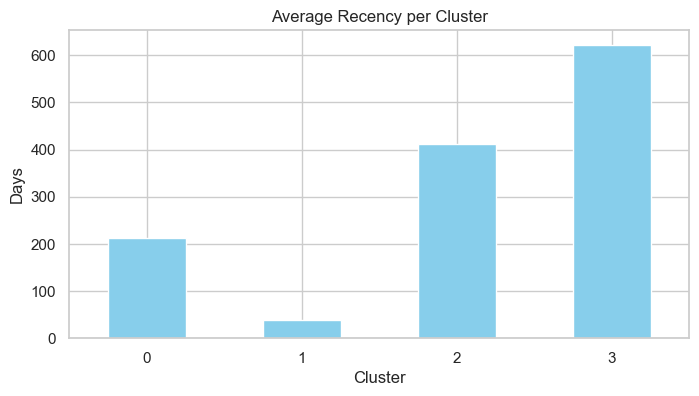

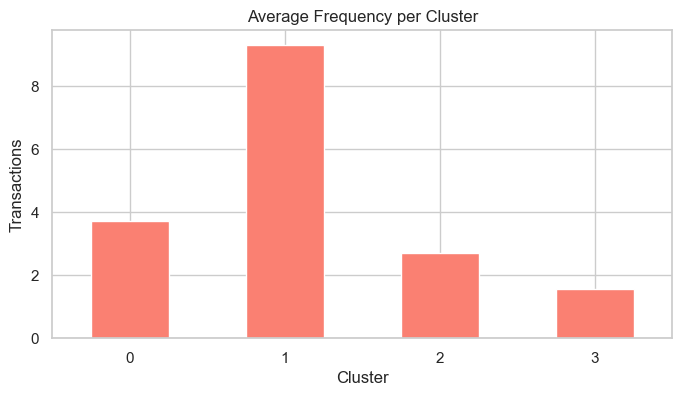

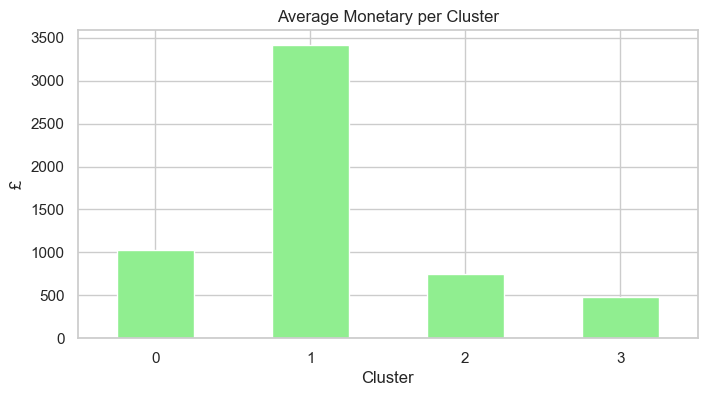

In [74]:
rfm_profile[['Recency (days)']].plot(kind='bar', figsize=(8, 4), color='skyblue', legend=False, rot=0)
plt.title('Average Recency per Cluster')
plt.ylabel('Days')
plt.xlabel('Cluster')
plt.show()

rfm_profile[['Frequency (transactions)']].plot(kind='bar', figsize=(8, 4), color='salmon', legend=False, rot=0)
plt.title('Average Frequency per Cluster')
plt.ylabel('Transactions')
plt.xlabel('Cluster')
plt.show()

rfm_profile[['Monetary (£)']].plot(kind='bar', figsize=(8, 4), color='lightgreen', legend=False, rot=0)
plt.title('Average Monetary per Cluster')
plt.ylabel('£')
plt.xlabel('Cluster')
plt.show()


## **Segmentation**

In [75]:
cluster_profile_unit = rfm_profile.copy()

rec_q1, rec_q2 = cluster_profile_unit['Recency (days)'].quantile([0.33, 0.66])
freq_q1, freq_q2 = cluster_profile_unit['Frequency (transactions)'].quantile([0.33, 0.66])
mon_q1, mon_q2 = cluster_profile_unit['Monetary (£)'].quantile([0.33, 0.66])

def get_level(value, q1, q2):
    if value <= q1:
        return "Low"
    elif value <= q2:
        return "Medium"
    else:
        return "High"

def rec_desc(level):
    if level == "Low":
        return "Recent / Frequent customer"
    elif level == "Medium":
        return "Moderate recency"
    else:
        return "Long time since last purchase / Inactive"

def freq_desc(level):
    if level == "Low":
        return "Purchases rarely"
    elif level == "Medium":
        return "Moderate purchase frequency"
    else:
        return "Purchases frequently"

def mon_desc(level):
    if level == "Low":
        return "Low transaction value"
    elif level == "Medium":
        return "Moderate transaction value"
    else:
        return "High transaction value"

def assign_segment(row):
    R = row['Recency_level']
    F = row['Frequency_level']
    M = row['Monetary_level']
    
    if R=="Low" and F=="High" and M=="High":
        return "🏆 Champion / Loyal Customers"
    elif R=="High" and F=="Low" and M=="Low":
        return "👻 Lost / At Risk"
    elif R in ["Medium","High"] and F in ["Low","Medium"] and M in ["Low","Medium"]:
        return "😴 Hibernating / Needs Attention"
    else:
        return "🌱 Potential / Promising"

cluster_profile_unit['Recency_level'] = cluster_profile_unit['Recency (days)'].apply(lambda x: get_level(x, rec_q1, rec_q2))
cluster_profile_unit['Frequency_level'] = cluster_profile_unit['Frequency (transactions)'].apply(lambda x: get_level(x, freq_q1, freq_q2))
cluster_profile_unit['Monetary_level'] = cluster_profile_unit['Monetary (£)'].apply(lambda x: get_level(x, mon_q1, mon_q2))

cluster_profile_unit['Recency_desc'] = cluster_profile_unit['Recency_level'].apply(rec_desc)
cluster_profile_unit['Frequency_desc'] = cluster_profile_unit['Frequency_level'].apply(freq_desc)
cluster_profile_unit['Monetary_desc'] = cluster_profile_unit['Monetary_level'].apply(mon_desc)

cluster_profile_unit['Segment'] = cluster_profile_unit.apply(assign_segment, axis=1)

cols_order = [
    'Recency (days)','Recency_level','Recency_desc',
    'Frequency (transactions)','Frequency_level','Frequency_desc',
    'Monetary (£)','Monetary_level','Monetary_desc',
    'Segment'
]

cluster_profile_unit[cols_order]

,Recency (days),Recency_level,Recency_desc,Frequency (transactions),Frequency_level,Frequency_desc,Monetary (£),Monetary_level,Monetary_desc,Segment
Cluster,,,,,,,,,,
0,213.31,Medium,Moderate recency,3.71,High,Purchases frequently,1032.79,High,High transaction value,🌱 Potential / Promising
1,37.89,Low,Recent / Frequent customer,9.31,High,Purchases frequently,3416.97,High,High transaction value,🏆 Champion / Loyal Customers
2,412.85,High,Long time since last purchase / Inactive,2.72,Medium,Moderate purchase frequency,751.34,Medium,Moderate transaction value,😴 Hibernating / Needs Attention
3,622.08,High,Long time since last purchase / Inactive,1.55,Low,Purchases rarely,476.54,Low,Low transaction value,👻 Lost / At Risk


In [76]:
segment_counts = (
    rfm
    .merge(cluster_profile_unit[['Segment']], left_on='Cluster', right_index=True)
    ['Segment']
    .value_counts()
    .reset_index()
)

segment_counts.columns = ['Segment', 'Customer_Count']
segment_counts


,Segment,Customer_Count
0,🏆 Champion / Loyal Customers,3145
1,😴 Hibernating / Needs Attention,1107
2,🌱 Potential / Promising,989
3,👻 Lost / At Risk,637


## Business Insights

In [77]:
cluster_profile_unit_reset = cluster_profile_unit.reset_index(drop=True)
cluster_profile_unit_reset['Cluster'] = cluster_profile_unit_reset.index

cluster_map = cluster_profile_unit_reset[['Cluster', 'Segment']]

rfm_segments = rfm.merge(cluster_map, on='Cluster', how='left')

rfm_segments['Segment'] = rfm_segments['Segment'] \
    .str.replace('🌱','') \
    .str.replace('🏆','') \
    .str.replace('👻','') \
    .str.replace('😴','')

rfm_segments.head()

,Customer ID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,12,77403.79,2,Hibernating / Needs Attention
1,12347.0,2,8,3434.23,1,Champion / Loyal Customers
2,12348.0,75,5,1448.56,1,Champion / Loyal Customers
3,12349.0,19,4,3018.85,1,Champion / Loyal Customers
4,12350.0,310,1,174.20,0,Potential / Promising


In [78]:
df_segments = df.merge(rfm_segments[['Customer ID','Segment']], on='Customer ID', how='left')

df_segments['InvoiceDate'] = pd.to_datetime(df_segments['InvoiceDate'])

df_segments['YearMonth'] = df_segments['InvoiceDate'].dt.to_period('M')

df_segments.columns

Index(['Customer ID', 'InvoiceDate', 'Quantity', 'Price', 'Invoice', 'Revenue',
       'Segment', 'YearMonth'],
      dtype='object')

In [79]:
monthly_customers = (
    df_segments.groupby(['YearMonth','Segment'])['Customer ID']
    .nunique()
    .reset_index()
    .rename(columns={'Customer ID':'TotalCustomers'})
)

monthly_customers.head()

,YearMonth,Segment,TotalCustomers
0,2009-12,Champion / Loyal Customers,601
1,2009-12,Hibernating / Needs Attention,115
2,2009-12,Lost / At Risk,143
3,2009-12,Potential / Promising,96
4,2010-01,Champion / Loyal Customers,439


Monitoring

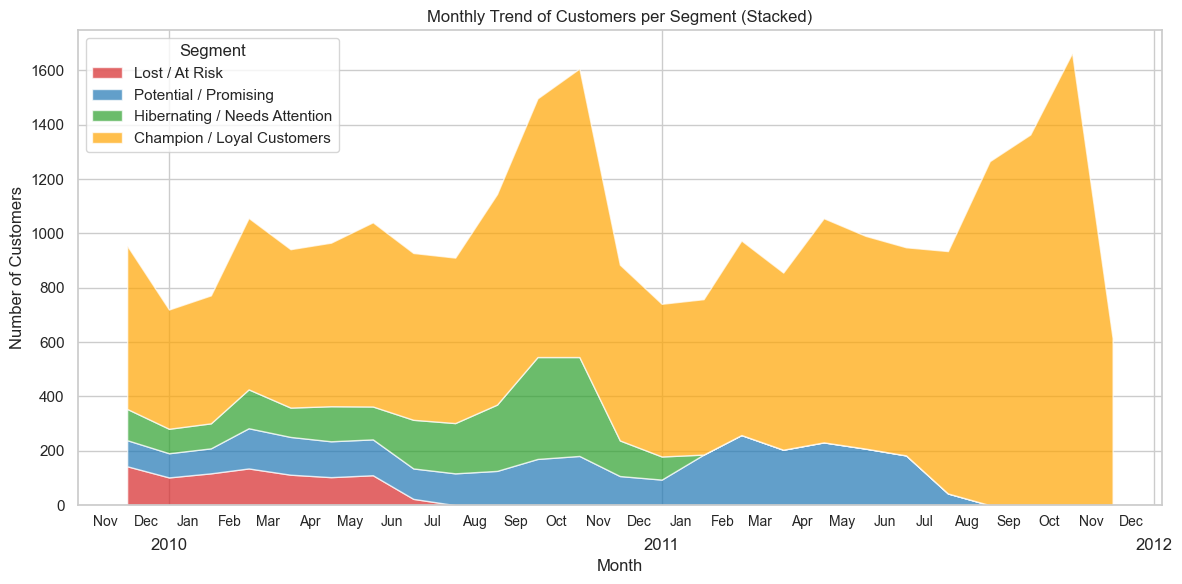

In [80]:
monthly_pivot = monthly_customers.pivot(index='YearMonth', columns='Segment', values='TotalCustomers').fillna(0)

monthly_pivot.columns = monthly_pivot.columns.str.strip()

segment_order = ['Champion / Loyal Customers',
                 'Hibernating / Needs Attention',
                 'Potential / Promising', 
                 'Lost / At Risk']

monthly_pivot = monthly_pivot[segment_order[::-1]]

segment_colors = {
    'Champion / Loyal Customers': '#FFA500',
    'Hibernating / Needs Attention': '#2ca02c',
    'Potential / Promising': '#1f77b4',
    'Lost / At Risk': '#d62728'
}
colors = [segment_colors[s] for s in monthly_pivot.columns]

plt.figure(figsize=(12,6))

plt.stackplot(
    monthly_pivot.index.to_timestamp(),
    *[monthly_pivot[col].values for col in monthly_pivot.columns],
    labels=monthly_pivot.columns,
    colors=colors,
    alpha=0.7
)

plt.title('Monthly Trend of Customers per Segment (Stacked)')
plt.xlabel('Month')
plt.ylabel('Number of Customers')

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=15))
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))

ax.tick_params(axis='x', which='major', pad=18, labelsize=12)
ax.tick_params(axis='x', which='minor', labelsize=10)

plt.legend(title='Segment', loc='upper left')
plt.tight_layout()
plt.show()


In [81]:
rfm_segments['Segment'] = rfm_segments['Segment'].str.strip()
df_segments['Segment'] = df_segments['Segment'].str.strip()

customer_count = rfm_segments.groupby('Segment')['Customer ID'].nunique().reindex(segment_order)

revenue_segment = df_segments.groupby('Segment')['Revenue'].sum().reindex(segment_order)

aov_segment = df_segments.groupby('Segment')['Revenue'].apply(
    lambda rev: rev.sum() / rev.index.nunique()
).reindex(segment_order)

colors = [segment_colors[s] for s in segment_order]

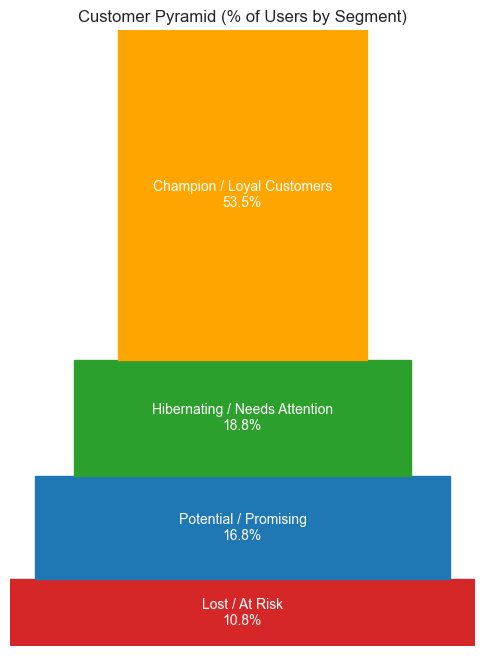

In [82]:
percent = customer_count.values / customer_count.sum()
segments = segment_order[::-1]
percent = percent[::-1]

fig, ax = plt.subplots(figsize=(6,8))

bottom = 0
for s, p in zip(segments, percent):
    left = 0.5 - (1 - bottom) / 2
    right = 0.5 + (1 - bottom) / 2
    xs = [left, right, right, left]
    ys = [bottom, bottom, bottom + p, bottom + p]
    ax.fill(xs, ys, color=segment_colors.get(s, '#888888'))
    ax.text(0.5, bottom + p/2, f"{s}\n{p*100:.1f}%", ha='center', va='center', color='white', fontsize=10)
    bottom += p

ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.axis('off')
plt.title('Customer Pyramid (% of Users by Segment)')
plt.show()

AOV (Average Order Value): The average amount of money a customer spends each time they place an order.

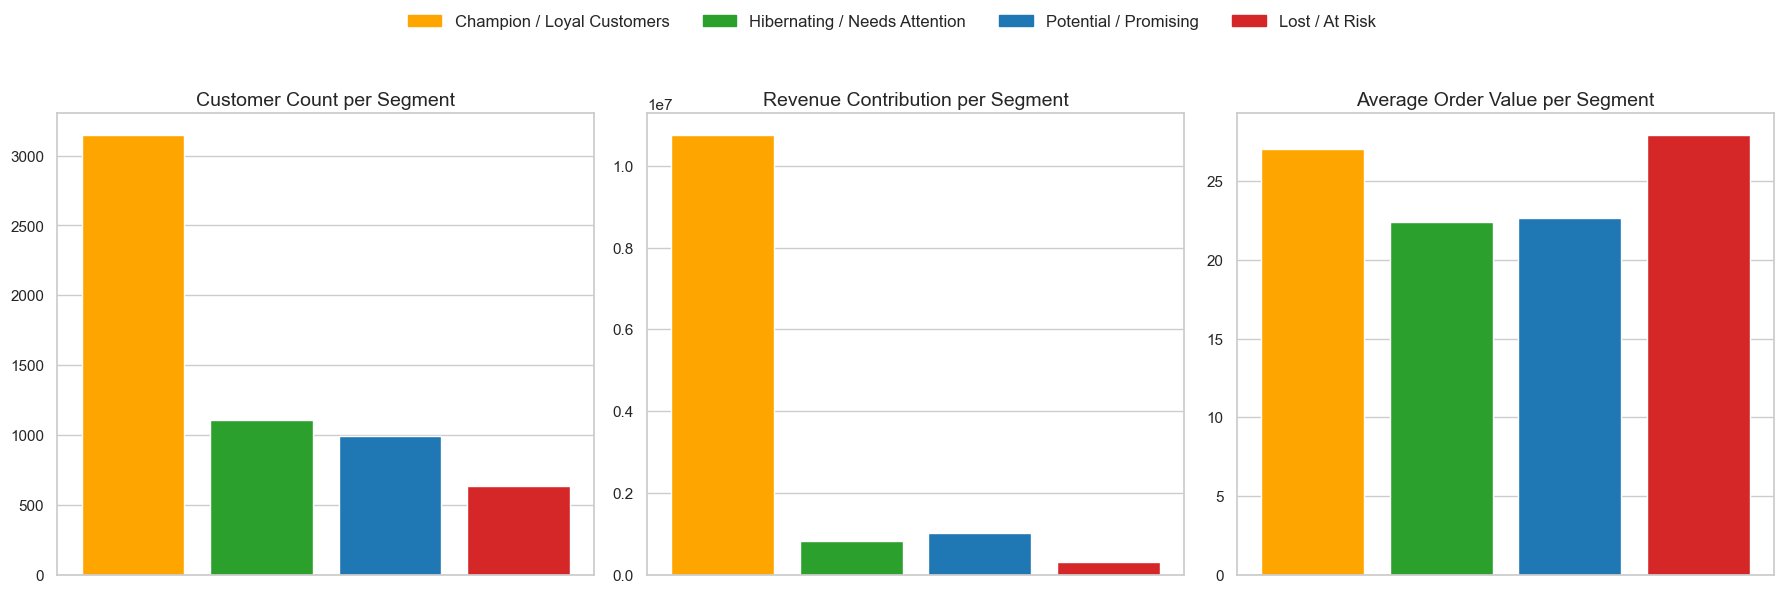

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

axes[0].bar(segment_order, customer_count.values, color=colors)
axes[0].set_title('Customer Count per Segment', fontsize=14)
axes[0].set_xticks([])

axes[1].bar(segment_order, revenue_segment.values, color=colors)
axes[1].set_title('Revenue Contribution per Segment', fontsize=14)
axes[1].set_xticks([])

axes[2].bar(segment_order, aov_segment.values, color=colors)
axes[2].set_title('Average Order Value per Segment', fontsize=14)
axes[2].set_xticks([])

legend_patches = [Patch(color=segment_colors[s], label=s) for s in segment_order]
fig.legend(handles=legend_patches, loc='upper center', ncol=4, frameon=False, fontsize=12)

plt.tight_layout(rect=[0,0,1,0.88])
plt.show()

In [84]:
aov_segment

Segment
Champion / Loyal Customers       27.024776
Hibernating / Needs Attention    22.411366
Potential / Promising            22.685251
Lost / At Risk                   27.923524
Name: Revenue, dtype: float64

In [85]:
print("Customer Count per Segment:")
print(customer_count)
print("\nRevenue per Segment (£):")
print(revenue_segment)
print("\nAverage Order Value (AOV) per Segment (£):")
print(aov_segment)

Customer Count per Segment:
Segment
Champion / Loyal Customers       3145
Hibernating / Needs Attention    1107
Potential / Promising             989
Lost / At Risk                    637
Name: Customer ID, dtype: int64

Revenue per Segment (£):
Segment
Champion / Loyal Customers       1.074638e+07
Hibernating / Needs Attention    8.317306e+05
Potential / Promising            1.021426e+06
Lost / At Risk                   3.035566e+05
Name: Revenue, dtype: float64

Average Order Value (AOV) per Segment (£):
Segment
Champion / Loyal Customers       27.024776
Hibernating / Needs Attention    22.411366
Potential / Promising            22.685251
Lost / At Risk                   27.923524
Name: Revenue, dtype: float64


Segment Migration

In [86]:
snapshot_date = df_segments['InvoiceDate'].max() + pd.Timedelta(days=1)

monthly_rfm = df_segments.groupby(['Customer ID','YearMonth']).agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

def compute_quantiles(df):
    rec_q1, rec_q2 = df['Recency'].quantile([0.33, 0.66])
    freq_q1, freq_q2 = df['Frequency'].quantile([0.33, 0.66])
    mon_q1, mon_q2 = df['Monetary'].quantile([0.33, 0.66])
    return rec_q1, rec_q2, freq_q1, freq_q2, mon_q1, mon_q2

monthly_rfm['Recency_level'] = None
monthly_rfm['Frequency_level'] = None
monthly_rfm['Monetary_level'] = None
monthly_rfm['Segment'] = None

for period, group in monthly_rfm.groupby('YearMonth'):
    rec_q1, rec_q2, freq_q1, freq_q2, mon_q1, mon_q2 = compute_quantiles(group)
    
    idx = group.index
    monthly_rfm.loc[idx, 'Recency_level'] = group['Recency'].apply(lambda x: get_level(x, rec_q1, rec_q2))
    monthly_rfm.loc[idx, 'Frequency_level'] = group['Frequency'].apply(lambda x: get_level(x, freq_q1, freq_q2))
    monthly_rfm.loc[idx, 'Monetary_level'] = group['Monetary'].apply(lambda x: get_level(x, mon_q1, mon_q2))
    
    monthly_rfm.loc[idx, 'Segment'] = monthly_rfm.loc[idx].apply(assign_segment, axis=1)

monthly_rfm = monthly_rfm.sort_values(['Customer ID','YearMonth'])
monthly_rfm['Prev_Segment'] = monthly_rfm.groupby('Customer ID')['Segment'].shift(1)

transition_matrix = pd.crosstab(
    monthly_rfm['Prev_Segment'], monthly_rfm['Segment'], 
    normalize='index'
).fillna(0)

transition_matrix

Segment,🌱 Potential / Promising,🏆 Champion / Loyal Customers,👻 Lost / At Risk,😴 Hibernating / Needs Attention
Prev_Segment,,,,
🌱 Potential / Promising,0.526630,0.111449,0.095093,0.266827
🏆 Champion / Loyal Customers,0.458472,0.341777,0.040698,0.159053
👻 Lost / At Risk,0.399809,0.043998,0.215208,0.340985
😴 Hibernating / Needs Attention,0.451056,0.064261,0.127465,0.357218


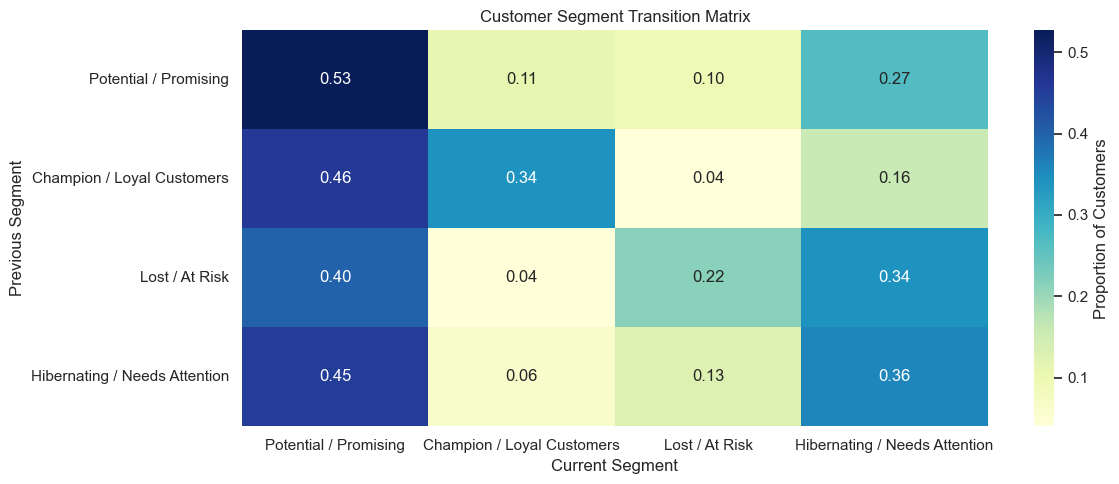

In [87]:
transition_matrix.index = transition_matrix.index.str.replace(r'[^\w\s/]', '', regex=True).str.strip()
transition_matrix.columns = transition_matrix.columns.str.replace(r'[^\w\s/]', '', regex=True).str.strip()

plt.figure(figsize=(12,5))
sns.heatmap(
    transition_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Proportion of Customers'}
)
plt.title("Customer Segment Transition Matrix")
plt.ylabel("Previous Segment")
plt.xlabel("Current Segment")
plt.yticks(rotation=0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

| Prev Segment                     | Potential | Champion | Lost  | Hibernating | Key Insight                                                                 |
|---------------------------------|-----------|---------|-------|-------------|----------------------------------------------------------------------------|
| Potential / Promising            | 0.527     | 0.111   | 0.095 | 0.267       | ~53% stay Potential, 11% upgrade to Champion, 27% at risk.                 |
| Champion / Loyal                 | 0.458     | 0.342   | 0.041 | 0.159       | Only 34% retain Champion status; 46% drop to Potential — retention is fragile. |
| Lost / At Risk                   | 0.400     | 0.044   | 0.215 | 0.341       | ~40% recover as Potential, 34% stay Hibernating — moderate win-back potential. |
| Hibernating / Needs Attention    | 0.451     | 0.064   | 0.127 | 0.357       | 36% remain Hibernating, 45% slide to Potential — risk of churn is high.  |

## RFM Personas & Recommendations

| Segment | Persona Description | Key Recommendation |
| - | - | - |
| Champion / Loyal Customers    | Frequent, high-spending, recent purchasers. Core revenue contributors.            | VIP programs, loyalty rewards, early access to products. Focus on retention.                |
| Potential / Promising         | Recent or moderately frequent buyers, mid-value transactions. Growth opportunity. | Upsell/cross-sell campaigns, personalized recommendations, incentives to move to Champions. |
| Hibernating / Needs Attention | Infrequent buyers, mid-low transaction value, inactive for a while.               | Re-engagement campaigns: email reminders, discounts, special offers to prevent churn.       |
| Lost / At Risk                | Rare or no recent purchases, high AOV historically.                               | Win-back campaigns: exclusive offers, targeted communication, highlight new products.       |